# Lid-Driven Cavity Flow

In this file, we solve the classic lid-driven flow porblem. I.e., we solve the following boundary value condition:

$$\begin{gather*}
     u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = -\frac{\partial p}{\partial x} + \nu\left(\frac{\partial^2u}{\partial x^2} + \frac{\partial^2u}{\partial y^2}\right) \\
     u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = -\frac{\partial p}{\partial y} + \nu\left(\frac{\partial^2v}{\partial x^2} + \frac{\partial^2v}{\partial y^2}\right),
\end{gather*}$$

where $u = \frac{\partial \psi}{\partial y}$ and $v = -\frac{\partial \psi}{\partial x}$, where $\psi$ is the stream function and $p$ is the pressure.\
The domain of interest is $\Omega = [-0.5,\,0.5]\times[-0.5,\,0.5]$. Furthermore, we enforce the following boundary conditions:

$$\begin{align*}
     u(x, 1) = 1 \quad&\land\quad v(x, 1) = 0 \\
     u(x, y) = 0 \quad&\land\quad v(x, y) = 0 \quad\text{ on other boundaries.}
\end{align*}$$

In [1]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm
from typing import Tuple

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
NU = 0.001
RE = 1 / NU
T_MAX = 1
L_BOUNDS = [-0.5, -0.5]
U_BOUNDS = [0.5, 0.5]
A = 0.3  # used during training to select A percentage of points with smallest detection metric

In [ ]:
def pde_res(model: torch.nn.Module, input: torch.Tensor):
    _, _, u, v, u_x, u_y, v_x, v_y, u_xx, u_yy, v_xx, v_yy, p_x, p_y = calc.compute_derivatives_ns(model, input)
    res_a = u * u_x + v * u_y + p_x - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y + p_y - NU * (v_xx + v_yy)
    return res_a, res_b


def SDF_weights(x: torch.Tensor) -> torch.Tensor:
    return 1.0 - 2.0 * torch.abs(x[:, 0:1])


def loss_fn(model: torch.nn.Module, domain: cb.CubeDomain):
    # PDE loss
    pde_input = domain.interior.requires_grad_(True)
    res_a, res_b = pde_res(model, pde_input)
    pde_loss = torch.mean(res_a**2 + res_b**2)

    # Top loss
    top_input = domain.sides[1][1].requires_grad_(True)
    psi_top = model(top_input)[:, 0:1]
    psi_top_grad = grad(psi_top, top_input, torch.ones_like(psi_top), create_graph=True)[0]
    u_top, v_top = psi_top_grad[:, 1:2], -psi_top_grad[:, 0:1]
    top_weigths = SDF_weights(top_input)
    top_loss = torch.sum(top_weigths * ((u_top - 0.25)**2 + v_top**2)) / torch.sum(top_weigths)

    # Side loss
    side_input = torch.cat([domain.sides[0][0], domain.sides[0][1], domain.sides[1][0]], dim=0).requires_grad_(True)
    psi_sides = model(side_input)[:, 0:1]
    psi_sides_grad = grad(psi_sides, side_input, torch.ones_like(psi_sides), create_graph=True)[0]
    u_side, v_side = psi_sides_grad[:, 1:2], -psi_sides_grad[:, 0:1]
    side_loss = torch.mean(u_side**2 + v_side**2)
    
    #experimental
    res = torch.sqrt(res_a**2 + res_b**2)
    res_grad = grad(res, pde_input, torch.ones_like(res), create_graph=True)[0]
    res_grad_norm = torch.norm(res_grad, dim=1)
    res_loss = torch.max(res_grad_norm)
    
    return [pde_loss, top_loss, side_loss, res_loss]

In [5]:
# define domain context
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=4_000,
    N_sides=[(500, 500), (500, 1000)],
)

domain = cb.CubeDomain(domain_ctx)

In [6]:
# define model context
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    layer = [32, 32, 32, 32],
    u_bounds=U_BOUNDS,
    l_bounds=L_BOUNDS
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
# define training context
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss_fn,
    resample=False,
    epochs=60_000
)

# train
domain.generate_points()
total_loss_values_1, component_loss_values_1 = train.simple_train(train_ctx)
train_ctx.optimizer = optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
total_loss_values_2, component_loss_values_2 = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.05)

Loss at epoch 1 is: 49539.421875. 


KeyboardInterrupt: 

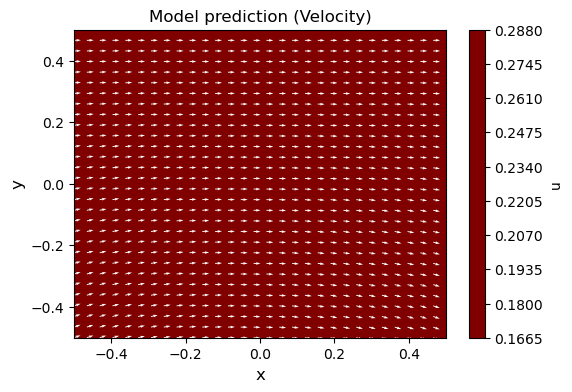

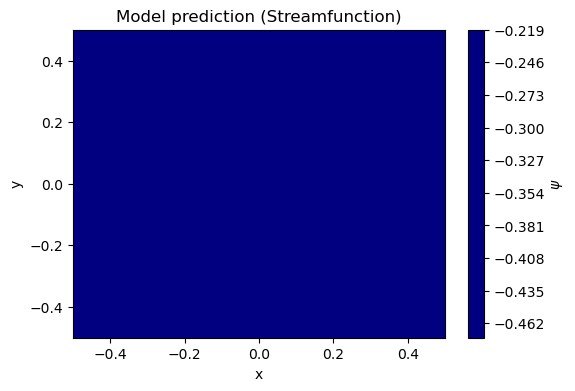

In [ ]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=0.1,
    patches=[],
    N = 100
)

# 
def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    psi = model(x)[:, 0]
    psi_grad = grad(psi, x, torch.ones_like(psi), create_graph=True)[0]
    
    return torch.cat([psi_grad[:, 1:2], -psi_grad[:, 0:1]], dim=1)

utils.plot_vector_field_2d([velocity], plot_ctx, N=100, n_width=30, n_heigth=30)

plot_ctx.vmin=-0.2
plot_ctx.vmax=-0
plot_ctx.titles = ['Model prediction (Streamfunction)']
plot_ctx.function_names = [r'$\psi$']

utils.plot_function_on_2d_cube([lambda x: model(x)[:, 0]], plot_ctx)

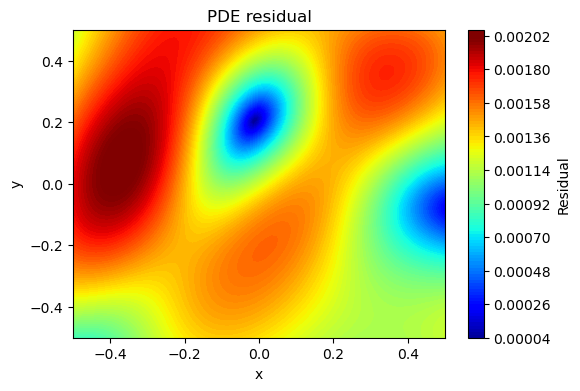

In [ ]:
plot_ctx.vmax = 0.1
plot_ctx.titles = ['PDE residual']
plot_ctx.function_names = ['Residual']
plot_ctx.vmin=0.0
plot_ctx.vmax=0.002

def pde_res_grad(x):
    x = x.requires_grad_(True)
    res_a, res_b = pde_res(model, x)
    
    res = res_a**2 + res_b**2
    
    res_grad = grad(res, x, torch.ones_like(res))[0]
    
    return torch.norm(res_grad, dim=1)

utils.plot_function_on_2d_cube([pde_res_grad], plot_ctx)

In [ ]:
plot_ctx.titles = ['Training Loss']
plot_ctx.x_label = 'Epochs'
plot_ctx.y_label = 'Loss'

utils.plot_loss_values({"Total loss": total_loss_values_1 + total_loss_values_2}, plot_ctx)

NameError: name 'total_loss_values_1' is not defined